# Plot bateau

In [23]:
import os
from google.colab import drive
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.image as mpimg
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim

drive.mount('/content/drive')
path_to_project = '/content/drive/MyDrive/IC/projetIC/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


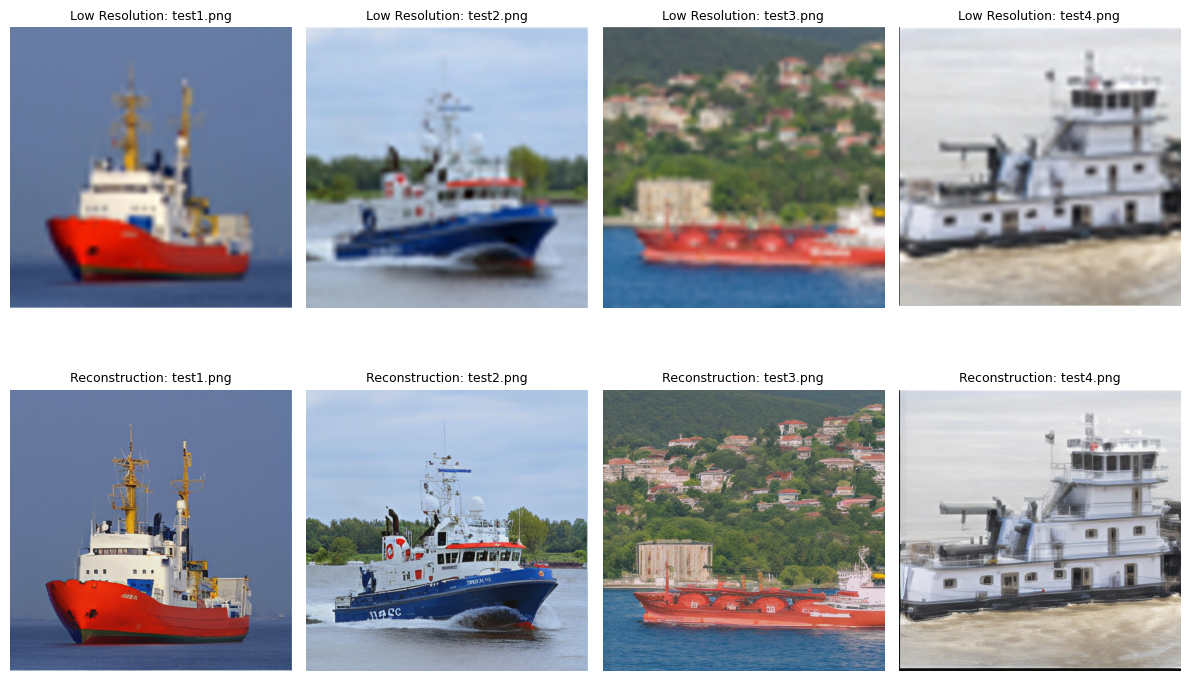

In [24]:
# --- CONFIGURATION ---
folder_a = path_to_project + "projet_robin/inputs/test_example/"
folder_b = path_to_project + "projet_robin/output_dir/test_example/"

files = sorted([f for f in os.listdir(folder_a) if f.endswith('.png')])[:4]

# Création de la figure : 2 lignes (A et B), 4 colonnes (les fichiers)
# figsize=(largeur, hauteur) -> Largeur augmentée pour tenir les 4 images
fig, axes = plt.subplots(nrows=2, ncols=len(files), figsize=(12, 8))

for i, filename in enumerate(files):
    path_a = os.path.join(folder_a, filename)
    path_b = os.path.join(folder_b, filename)

    # --- Ligne 1 : Dossier A ---
    ax_a = axes[0, i]
    img_a = mpimg.imread(path_a)
    ax_a.imshow(img_a)
    ax_a.set_title(f"Low Resolution: {filename}", fontsize=9)
    ax_a.axis('off')

    # --- Ligne 2 : Dossier B ---
    ax_b = axes[1, i]
    if os.path.exists(path_b):
        img_b = mpimg.imread(path_b)
        ax_b.imshow(img_b)
        ax_b.set_title(f"Reconstruction: {filename}", fontsize=9)
    else:
        ax_b.text(0.5, 0.5, "Manquant", ha='center', va='center')
    ax_b.axis('off')

# Ajustement automatique pour éviter les chevauchements
plt.tight_layout()
plt.show()

# Plot simu

In [25]:
def calc_perf(reference, test):
  results = {}
  imageGT=plt.imread(reference)
  imageY=plt.imread(test)

  if imageGT.ndim == 3:
    imageGT = imageGT[..., :3].mean(axis=2)
  if imageY.ndim == 3:
    imageY = imageY[..., :3].mean(axis=2)
  if imageGT.shape != imageY.shape:
    h, w = imageGT.shape
    imageY = cv2.resize(imageY, (w, h), interpolation=cv2.INTER_CUBIC)
  imageGT = np.clip(imageGT, 0, 1)
  imageY  = np.clip(imageY,  0, 1)

  results["MSE"] = np.mean((imageGT - imageY)**2)
  results["PSNR"] = 20*np.log10(1.0/np.sqrt(results["MSE"]))
  results["SSIM"] = ssim(imageGT, imageY, data_range=1.0)

  return results

In [26]:
folders = [path_to_project + "simu/GT/"
          , path_to_project + "projet_robin/inputs/simu/"
          , path_to_project + "projet_robin/output_dir/simu_base/"
          , path_to_project + "projet_robin/output_dir/simu_clip/"
          , path_to_project + "projet_robin/output_dir/simu_class/"
          , path_to_project + "projet_robin/output_dir/simu_clip_class/"]
columns_names = ["Ground truth (label)",
                 "Low-Resolution (input)",
                 "Base",
                 "Prompt",
                 "Classifier",
                 "Prompt and classifier"]
base_folder = folders[0]
files = sorted([f for f in os.listdir(base_folder) if f.endswith('.png')])[:4]

def get_metric(reference, test):
  results = calc_perf(reference, test)
  return f"MSE:{results["MSE"]:.5f}, SSIM:{results["SSIM"]:.2f}, PSNR:{results["PSNR"]:.2f}"

fig, axes = plt.subplots(nrows=len(files), ncols=len(folders),
                         figsize=(25, 20))
reference_temp = None
for row_idx, filename in enumerate(files):
    for col_idx, folder in enumerate(folders):
        ax = axes[row_idx, col_idx]
        path = os.path.join(folder, filename)

        if os.path.exists(path):
            img = mpimg.imread(path)
            ax.imshow(img, cmap='gray')
            if col_idx == 0:
              reference_temp = path
            else :
              metric_text = get_metric(reference_temp, path)
              ax.set_xlabel(metric_text, fontsize=12, fontweight='bold', color='darkblue')
        else:
            ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        if row_idx == 0:
            ax.set_title(f"{columns_names[col_idx]}", fontsize=14, fontweight='bold', pad=20)
        if col_idx == 0:
            ax.set_ylabel(f"bmode{row_idx}.png", fontsize=12, fontweight='bold', labelpad=20)

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Plot vivo

In [27]:
def calc_perf(reference, test):
  results = {}
  imageGT=plt.imread(reference)
  imageY=plt.imread(test)

  if imageGT.ndim == 3:
    imageGT = imageGT[..., :3].mean(axis=2)
  if imageY.ndim == 3:
    imageY = imageY[..., :3].mean(axis=2)
  if imageGT.shape != imageY.shape:
    h, w = imageGT.shape
    imageY = cv2.resize(imageY, (w, h), interpolation=cv2.INTER_CUBIC)
  imageGT = np.clip(imageGT, 0, 1)
  imageY  = np.clip(imageY,  0, 1)


  results["MSE"] = np.mean((imageGT - imageY)**2)
  results["PSNR"] = 20*np.log10(1.0/np.sqrt(results["MSE"]))
  results["SSIM"] = ssim(imageGT, imageY, data_range=1.0)

  return results

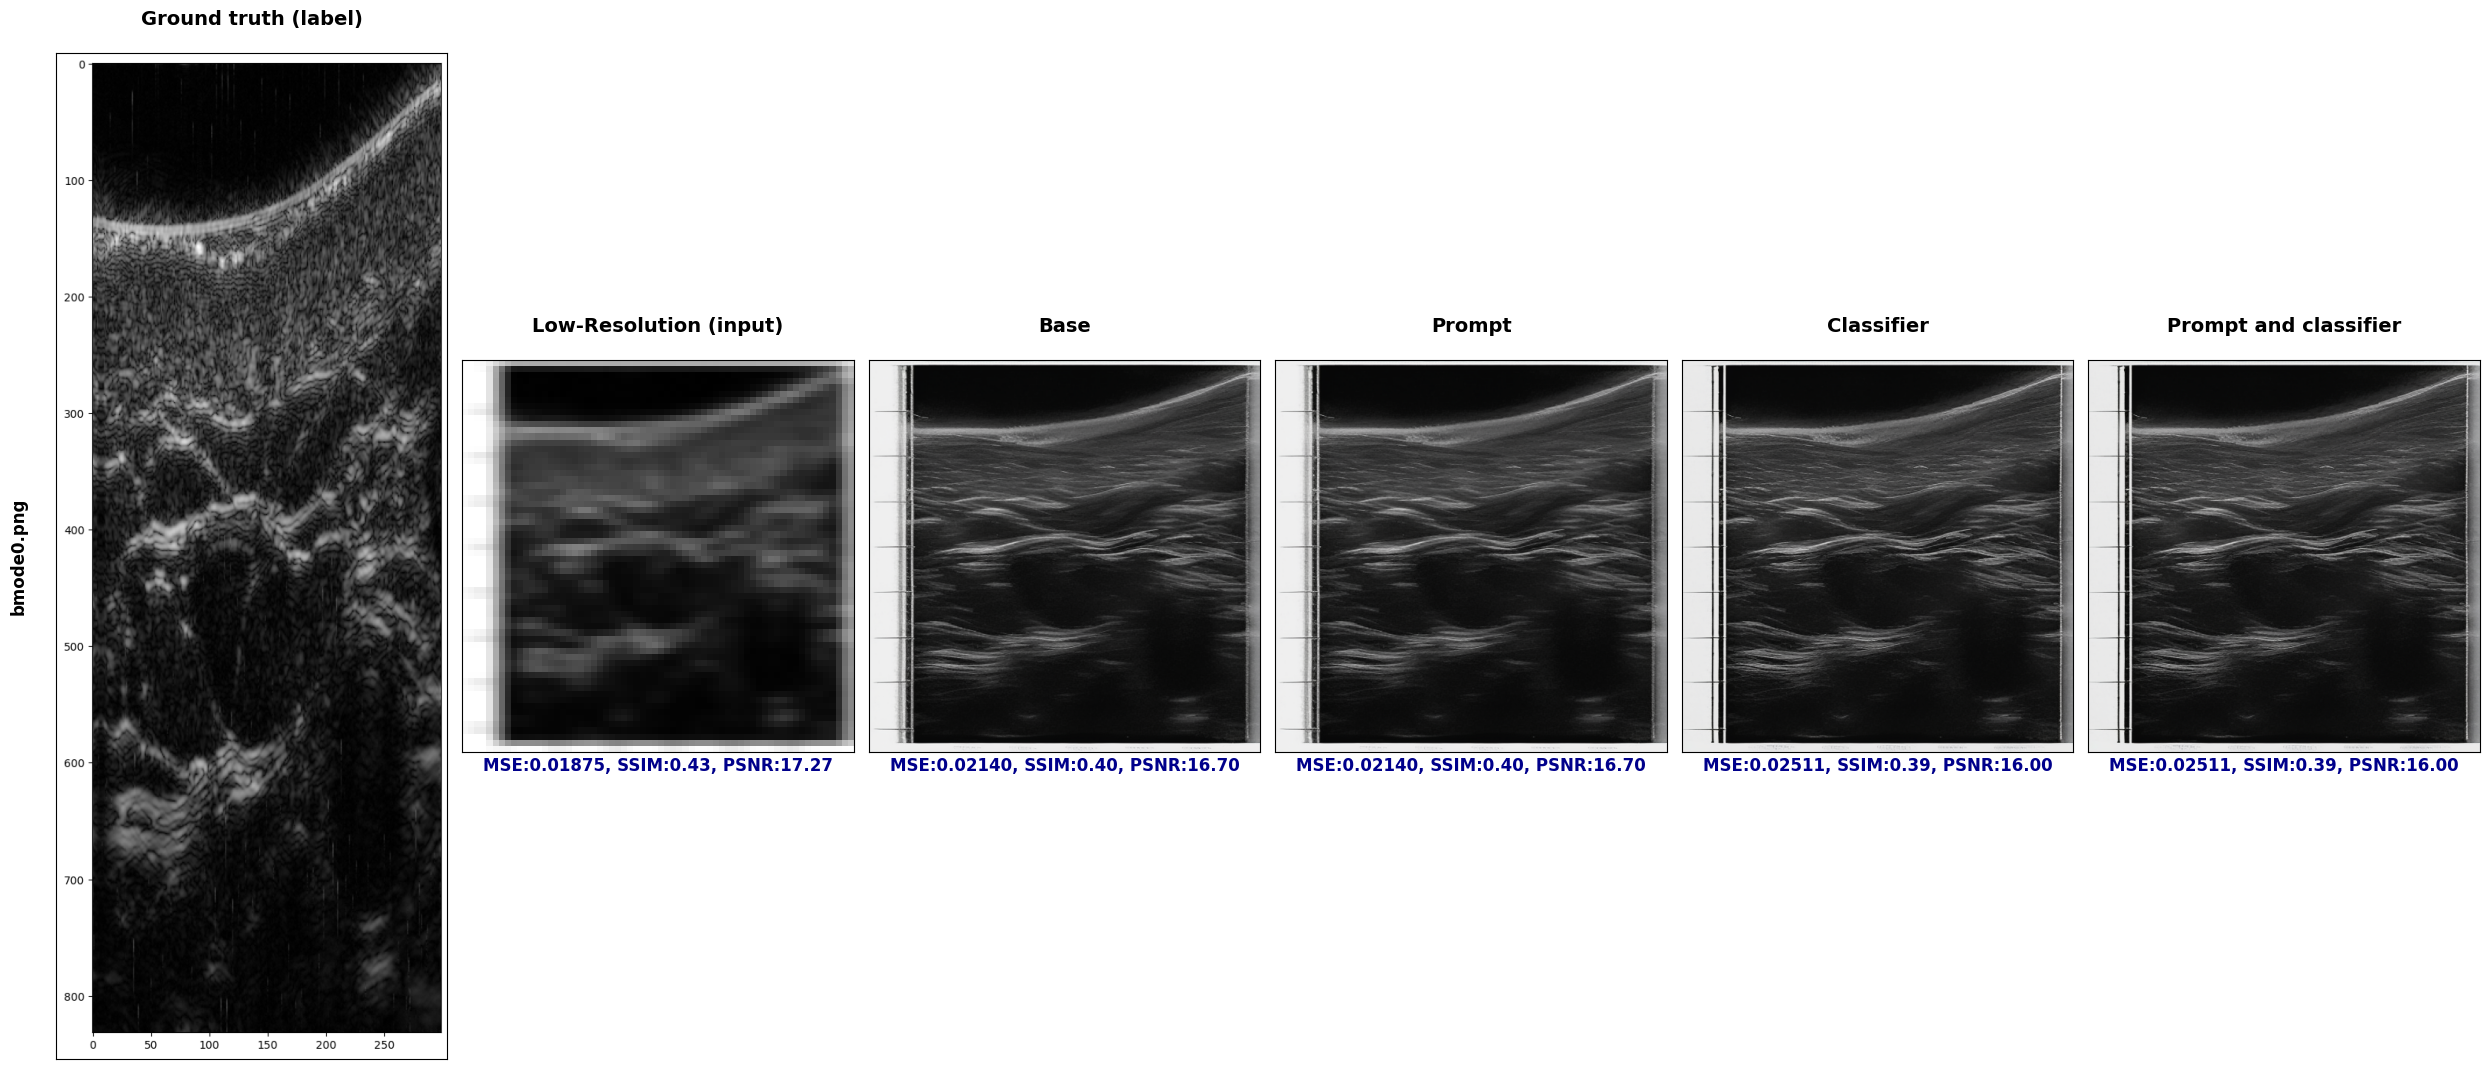

In [28]:
folders = [path_to_project + "vivo/GT/"
          , path_to_project + "projet_robin/inputs/vivo/"
          , path_to_project + "projet_robin/output_dir/vivo_base/"
          , path_to_project + "projet_robin/output_dir/vivo_clip/"
          , path_to_project + "projet_robin/output_dir/vivo_class/"
          , path_to_project + "projet_robin/output_dir/vivo_clip_class/"]
columns_names = ["Ground truth (label)",
                 "Low-Resolution (input)",
                 "Base",
                 "Prompt",
                 "Classifier",
                 "Prompt and classifier"]
base_folder = folders[0]
files = sorted([f for f in os.listdir(base_folder) if f.endswith('.png')])[:4]

def get_metric(reference, test):
  results = calc_perf(reference, test)
  return f"MSE:{results["MSE"]:.5f}, SSIM:{results["SSIM"]:.2f}, PSNR:{results["PSNR"]:.2f}"

fig, axes = plt.subplots(nrows=len(files), ncols=len(folders),
                         figsize=(25, 20),
                         squeeze=False)
reference_temp = None
for row_idx, filename in enumerate(files):
    for col_idx, folder in enumerate(folders):
        ax = axes[row_idx, col_idx]
        path = os.path.join(folder, filename)

        if os.path.exists(path):
            img = mpimg.imread(path)
            ax.imshow(img, cmap='gray')
            if col_idx == 0:
              reference_temp = path
            else :
              metric_text = get_metric(reference_temp, path)
              ax.set_xlabel(metric_text, fontsize=12, fontweight='bold', color='darkblue')
        else:
            ax.text(0.5, 0.5, "Image manquante", ha='center', va='center')
        if row_idx == 0:
            ax.set_title(f"{columns_names[col_idx]}", fontsize=14, fontweight='bold', pad=20)
        if col_idx == 0:
            ax.set_ylabel(f"bmode{row_idx}.png", fontsize=12, fontweight='bold', labelpad=20)

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()